# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

###I used a reduced subset of the SUSY dataset (500000 rows) because the full file caused memory issues on my local machine. The same workflow and analysis steps were applied.

In [10]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.display import HTML, display
import tabulate

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [3]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename,nrows=500000, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [4]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


I read through the scikit-learn classification documentation, the linear models section, and the Linear Discriminant Analysis documentation. I reviewed how classifiers are trained using input features X and labels y, and how the data is split into training and testing samples for unbiased performance evaluation.

### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [13]:
RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = [x for x in VarNames[1:] if x not in RawNames]
AllNames = VarNames[1:]

N_Train = 400000

Train_Sample = df[:N_Train].copy()
Test_Sample = df[N_Train:].copy()

X_Train = Train_Sample[AllNames].to_numpy()
y_Train = Train_Sample["signal"].to_numpy()

X_Test = Test_Sample[AllNames].to_numpy()
y_Test = Test_Sample["signal"].to_numpy()

# signal and background from the TEST FEATURES, not from original dataframe
X_Test_sig = X_Test[y_Test == 1]
X_Test_bkg = X_Test[y_Test == 0]

print("X_Train shape:", X_Train.shape)
print("X_Test shape:", X_Test.shape)
print("X_Test_sig shape:", X_Test_sig.shape)
print("X_Test_bkg shape:", X_Test_bkg.shape)

X_Train shape: (400000, 18)
X_Test shape: (100000, 18)
X_Test_sig shape: (45959, 18)
X_Test_bkg shape: (54041, 18)


As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [14]:
Fisher = LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


We can train the classifier as follow:

We can plot the output, comparing signal and background:

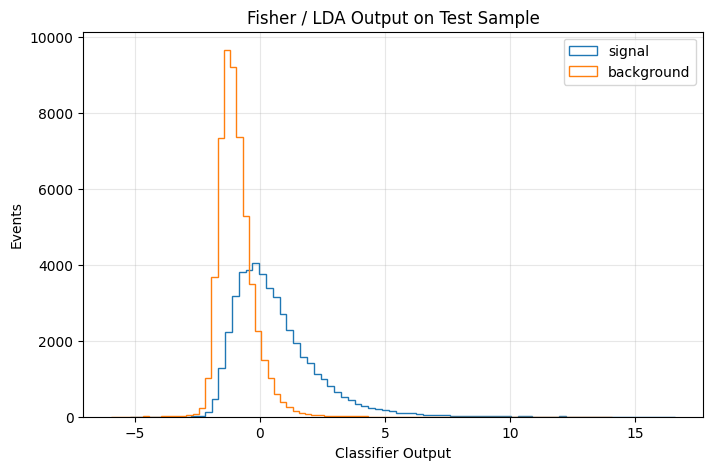

In [15]:
plt.figure(figsize=(8, 5))

sig_scores = Fisher.decision_function(X_Test_sig)
bkg_scores = Fisher.decision_function(X_Test_bkg)

plt.hist(sig_scores, bins=80, histtype="step", label="signal")
plt.hist(bkg_scores, bins=80, histtype="step", label="background")

plt.legend(loc="upper right")
plt.title("Fisher / LDA Output on Test Sample")
plt.xlabel("Classifier Output")
plt.ylabel("Events")
plt.grid(alpha=0.3)
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

The train ROC is usually a little better than the test ROC. This is expected. In my result, the two curves are close, so the model does not show strong overfitting.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [17]:
def get_scores(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    elif hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    else:
        return model.predict(X)

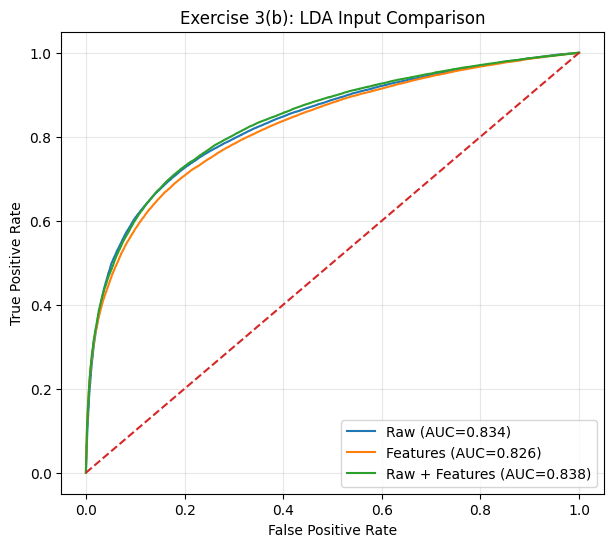

In [18]:
def fit_and_plot_lda(feature_list, label):
    clf = LinearDiscriminantAnalysis()
    clf.fit(Train_Sample[feature_list], y_Train)
    scores = get_scores(clf, Test_Sample[feature_list])
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")
    return roc_auc

plt.figure(figsize=(7, 6))

auc_raw = fit_and_plot_lda(RawNames, "Raw")
auc_feat = fit_and_plot_lda(FeatureNames, "Features")
auc_all = fit_and_plot_lda(AllNames, "Raw + Features")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 3(b): LDA Input Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

From the ROC comparison, the classifier trained with raw + features gives the best performance because it has the highest AUC. The raw-only model also performs well, while the features-only model is slightly worse. This suggests that combining raw observables with derived features improves the signal-background discrimination.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [19]:
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
}

In [20]:
def compare_classifier_inputs(model, model_name):
    plt.figure(figsize=(7, 6))

    for feature_list, label in [
        (RawNames, "Raw"),
        (FeatureNames, "Features"),
        (AllNames, "Raw + Features")
    ]:
        clf = model
        clf.fit(Train_Sample[feature_list], y_Train)
        scores = get_scores(clf, Test_Sample[feature_list])
        fpr, tpr, _ = roc_curve(y_Test, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name}: Raw vs Features vs Raw+Features")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

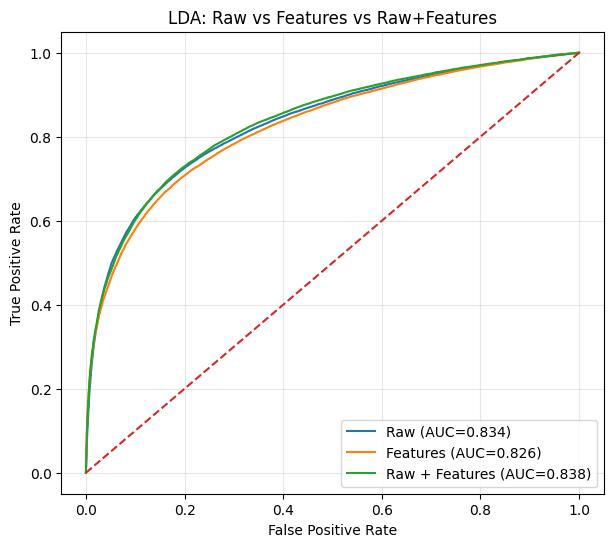

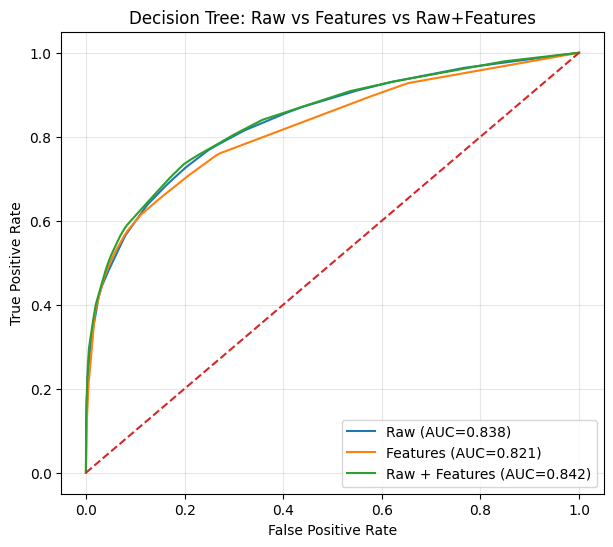

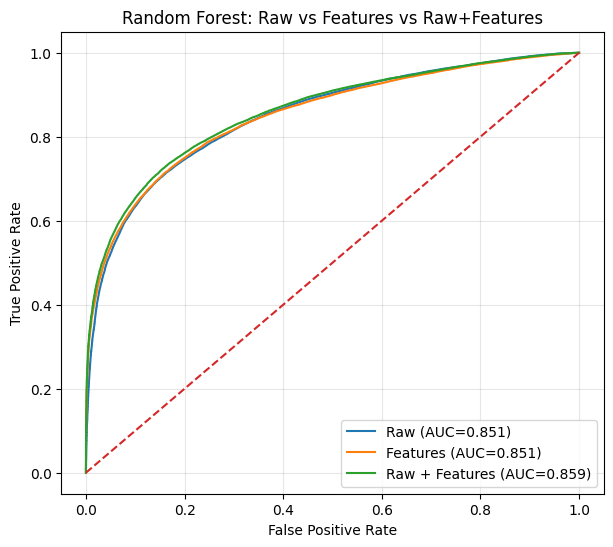

In [21]:
for name, model in models.items():
    compare_classifier_inputs(model, name)

In [22]:
best_name = None
best_model = None
best_auc = -1

results = []

for name, model in models.items():
    clf = model
    clf.fit(X_Train, y_Train)
    scores = get_scores(clf, X_Test)
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    results.append([name, roc_auc])

    if roc_auc > best_auc:
        best_auc = roc_auc
        best_name = name
        best_model = clf

result_df = pd.DataFrame(results, columns=["Model", "Test AUC"])
result_df = result_df.sort_values("Test AUC", ascending=False).reset_index(drop=True)
result_df

,Model,Test AUC
0,Random Forest,0.859098
1,Decision Tree,0.842029
2,LDA,0.838428


I compared three classifiers: LDA, Decision Tree, and Random Forest. Based on the test AUC values, Random Forest achieved the highest performance. Therefore, I selected Random Forest as the best classifier.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [24]:
def max_significance_from_scores(y_true, scores, NS, NB, n_points=200):
    thresholds = np.linspace(np.min(scores), np.max(scores), n_points)

    best_sigma = -1
    best_threshold = None
    best_tpr = None
    best_fpr = None

    for thr in thresholds:
        pred_signal = scores >= thr

        tp = np.sum((pred_signal == 1) & (y_true == 1))
        fp = np.sum((pred_signal == 1) & (y_true == 0))
        fn = np.sum((pred_signal == 0) & (y_true == 1))
        tn = np.sum((pred_signal == 0) & (y_true == 0))

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        S = NS * tpr
        B = NB * fpr

        sigma = S / np.sqrt(S + B) if (S + B) > 0 else 0.0

        if sigma > best_sigma:
            best_sigma = sigma
            best_threshold = thr
            best_tpr = tpr
            best_fpr = fpr

    return best_sigma, best_threshold, best_tpr, best_fpr

In [26]:
best_scores = get_scores(best_model, X_Test)

SCENARIOS = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

sig_rows = []

for NS, NB in SCENARIOS:
    sigma, thr, tpr_star, fpr_star = max_significance_from_scores(
        y_Test, best_scores, NS, NB
    )
    sig_rows.append([best_name, NS, NB, thr, tpr_star, fpr_star, sigma])

sig_df = pd.DataFrame(sig_rows, columns=[
    "Best Model", "N_S", "N_B", "Best Threshold", "TPR", "FPR", "Max Significance"
])

sig_df

,Best Model,N_S,N_B,Best Threshold,TPR,FPR,Max Significance
0,Random Forest,10,100,0.758051,0.454601,0.022446,1.744521
1,Random Forest,100,1000,0.758051,0.454601,0.022446,5.516659
2,Random Forest,1000,10000,0.758051,0.454601,0.022446,17.445208
3,Random Forest,10000,100000,0.758051,0.454601,0.022446,55.166591


Precision measures how many of the predicted signal events are actually signal. Recall measures how many of the true signal events are correctly identified. Accuracy measures the overall fraction of correct predictions. The F1 score combines precision and recall into a single value. ROC and AUC summarize the classifier performance over all possible thresholds and show how well the model separates signal from background.


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [28]:
metric_rows = []

fpr_curve, tpr_curve, _ = roc_curve(y_Test, best_scores)
roc_auc = auc(fpr_curve, tpr_curve)

for NS, NB in SCENARIOS:
    sigma, thr, tpr_star, fpr_star = max_significance_from_scores(
        y_Test, best_scores, NS, NB
    )

    pred = (best_scores >= thr).astype(int)

    precision = precision_score(y_Test, pred)
    recall = recall_score(y_Test, pred)
    f1 = f1_score(y_Test, pred)
    acc = accuracy_score(y_Test, pred)

    metric_rows.append([
        NS, NB,
        tpr_star,
        fpr_star,
        roc_auc,
        precision,
        recall,
        f1,
        acc,
        sigma
    ])

metrics_df = pd.DataFrame(metric_rows, columns=[
    "N_S", "N_B", "TPR", "FPR", "AUC", "Precision",
    "Recall", "F1 Score", "Accuracy", "Max Significance"
])

display(HTML("<h4>Exercise 5(b): Metrics for the best classifier</h4>"))
display(HTML(tabulate.tabulate(np.round(metrics_df, 4), headers="keys", tablefmt="html", showindex=False)))

N_S,N_B,TPR,FPR,AUC,Precision,Recall,F1 Score,Accuracy,Max Significance
10,100,0.4546,0.0224,0.8591,0.9451,0.4546,0.6139,0.7372,1.7445
100,1000,0.4546,0.0224,0.8591,0.9451,0.4546,0.6139,0.7372,5.5167
1000,10000,0.4546,0.0224,0.8591,0.9451,0.4546,0.6139,0.7372,17.4452
10000,100000,0.4546,0.0224,0.8591,0.9451,0.4546,0.6139,0.7372,55.1666


The Random Forest classifier achieved the highest test AUC, so it was selected as the best model. Using this model, I computed the optimal threshold that maximizes the statistical significance for each scenario. The TPR and FPR remain constant because they depend on the classifier and threshold, while the significance increases with larger numbers of signal and background events. This shows that better statistics improve the ability to detect signal over background.